# ЛАБОРАТОРНАЯ РАБОТА № 5

**Тема**: Временные ряды.

**Постановка**: Провести предвраительный анализ и визуализацию данных. Определить тренд, сезонность, аномалии. Выполнить проверку на стационарность ряда. Построить модель прогнозирования. Оценить точность с помощью mae, rmse. Интерпретировать полученные результаты.

**Цель**: Получить практические навыки работы над врменными рядами.

## Загрузка данных

In [163]:
import warnings
warnings.filterwarnings('ignore')

### Установим красивые дефолтные настройки
### Может быть лень постоянно прописывать
### У графиков параметры цвета, размера, шрифта
### Можно положить их в словарь дефолтных настроек

import matplotlib as mlp

mlp.rcParams['lines.linewidth'] = 5
mlp.rcParams['xtick.major.size'] = 20
mlp.rcParams['xtick.major.width'] = 5
mlp.rcParams['xtick.labelsize'] = 20
mlp.rcParams['xtick.color'] = '#FF5533'

mlp.rcParams['ytick.major.size'] = 20
mlp.rcParams['ytick.major.width'] = 5
mlp.rcParams['ytick.labelsize'] = 20
mlp.rcParams['ytick.color'] = '#FF5533'

mlp.rcParams['axes.labelsize'] = 20
mlp.rcParams['axes.titlesize'] = 20
mlp.rcParams['axes.titlecolor'] = '#00B050'
mlp.rcParams['axes.labelcolor'] = '#00B050'

In [164]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [165]:
import pandas as pd

### Прочитаем табличку для 5 лабы
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/5 лаба/lab5.csv')

data.head(20)

,Date,Employees
0,1/1/1990,1064.5
1,2/1/1990,1074.5
2,3/1/1990,1090.0
3,4/1/1990,1097.4
4,5/1/1990,1108.7
5,6/1/1990,1123.5
6,7/1/1990,1134.2
7,8/1/1990,1137.4
8,9/1/1990,1128.8
9,10/1/1990,1106.8


In [166]:
data.dtypes

,0
Date,object
Employees,float64


In [167]:
data.shape

(348, 2)

In [168]:
### Проверка на дубликаты
print(f'дубликатов - {data.duplicated().sum()}')

дубликатов - 0


In [169]:
data['Date'] = pd.to_datetime(data['Date'])
data = data.set_index('Date')
data = data.sort_index()
data.head()

,Employees
Date,
1990-01-01,1064.5
1990-02-01,1074.5
1990-03-01,1090.0
1990-04-01,1097.4
1990-05-01,1108.7


In [170]:
data.describe()

,Employees
count,348.000000
mean,1452.506897
std,256.604914
min,1064.500000
25%,1238.050000
50%,1436.200000
75%,1586.300000
max,2022.100000


Порядок индекса: True


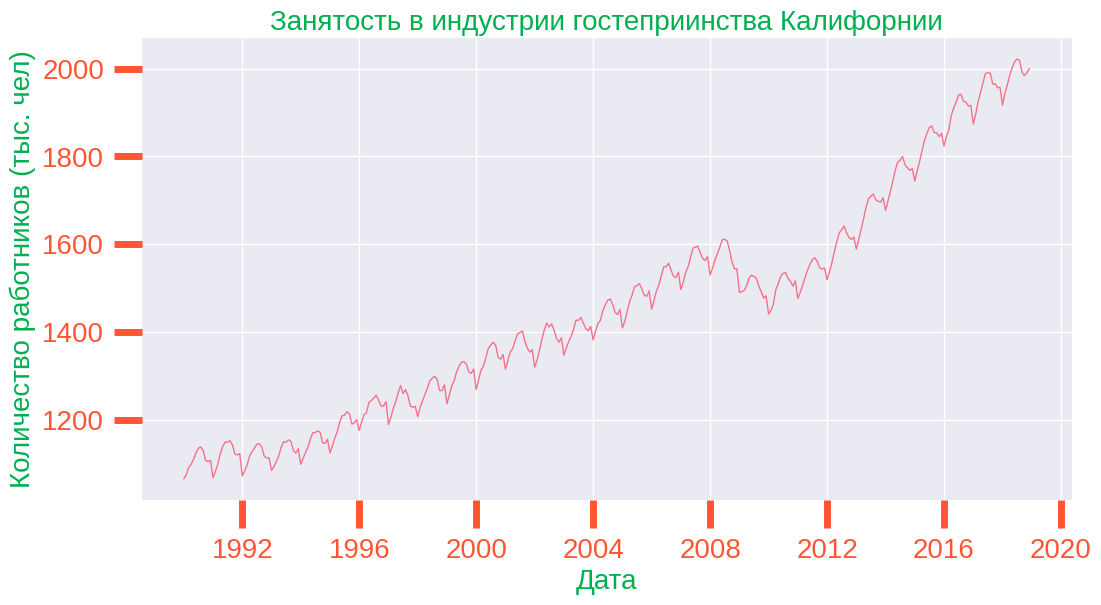

In [171]:
import matplotlib.pyplot as plt



# Сортируем по дате на всякий случай


# Проверяем порядок
print("Порядок индекса:", data.index.is_monotonic_increasing)

# График
plt.figure(figsize=(12, 6))
plt.plot(data.index, data.iloc[:, 0], linewidth=1)
plt.title('Занятость в индустрии гостеприинства Калифорнии')
plt.xlabel('Дата')
plt.ylabel('Количество работников (тыс. чел)')
plt.grid(True)
plt.show()


График показывает скачкообразное движение вверх как будто по линейной зависимости среднего, но с падением в 9/10 годах.
Резкое падение 2008-2011 годов может быть связано с мировым кризисом 2008 года.

Посмотрим как по сезонам распределена занятость.

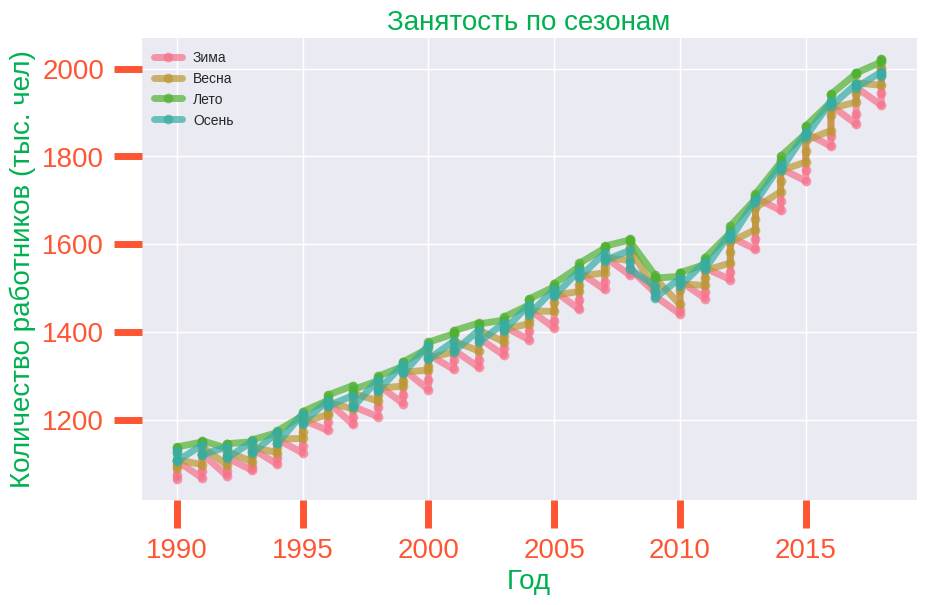

In [172]:
# График по сезонам
plt.figure(figsize=(10, 6))
seasons = {1: 'Зима', 2: 'Весна', 3: 'Лето', 4: 'Осень'}

for season in range(1, 5):
    season_data = data[data.index.month % 12 // 3 + 1 == season]
    plt.plot(season_data.index.year, season_data.iloc[:, 0],
             'o-', label=seasons[season], alpha=0.7)

plt.title('Занятость по сезонам')
plt.xlabel('Год')
plt.ylabel('Количество работников (тыс. чел)')
plt.legend()
plt.grid(True)
plt.show()

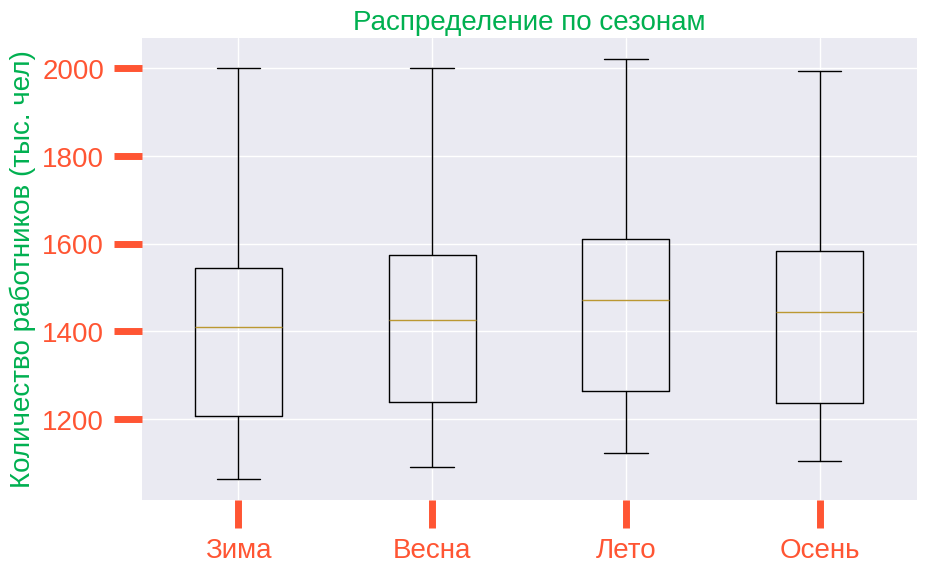

In [173]:
# Боксплот по сезонам
season_data = []
season_labels = []
for season in range(1, 5):
    season_mask = data.index.month % 12 // 3 + 1 == season
    season_data.append(data[season_mask].iloc[:, 0])
    season_labels.append(seasons[season])

plt.figure(figsize=(10, 6))
plt.boxplot(season_data, labels=season_labels)
plt.title('Распределение по сезонам')
plt.ylabel('Количество работников (тыс. чел)')
plt.grid(True)
plt.show()

по графикам сезонов и ящикам с усами можно сделать вывод, что сезонность проявляется ежегодно так, что в таком порядке по убыванию будут распределены большие занятости по временам года:
1. Лето
2. Осень
3. Весна
4. Зима



Попробуем определить тренд

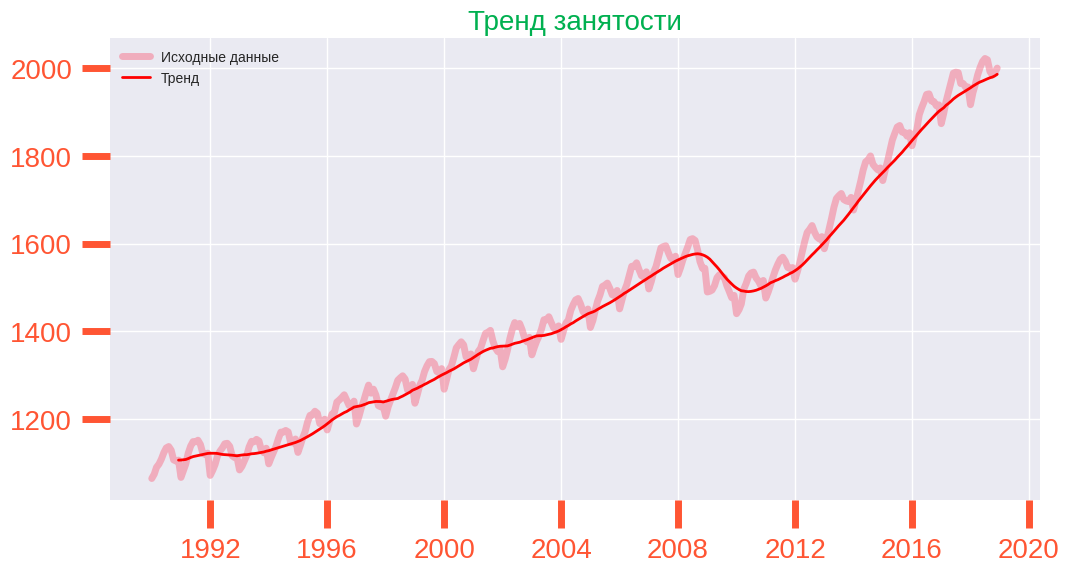

In [174]:
# Скользящее среднее для тренда
window = 12
trend = data.iloc[:, 0].rolling(window=window).mean()

# График с трендом
plt.figure(figsize=(12, 6))
plt.plot(data.index, data.iloc[:, 0], alpha=0.5, label='Исходные данные')
plt.plot(data.index, trend, linewidth=2, label='Тренд', color='red')
plt.title('Тренд занятости')
plt.legend()
plt.grid(True)
plt.show()

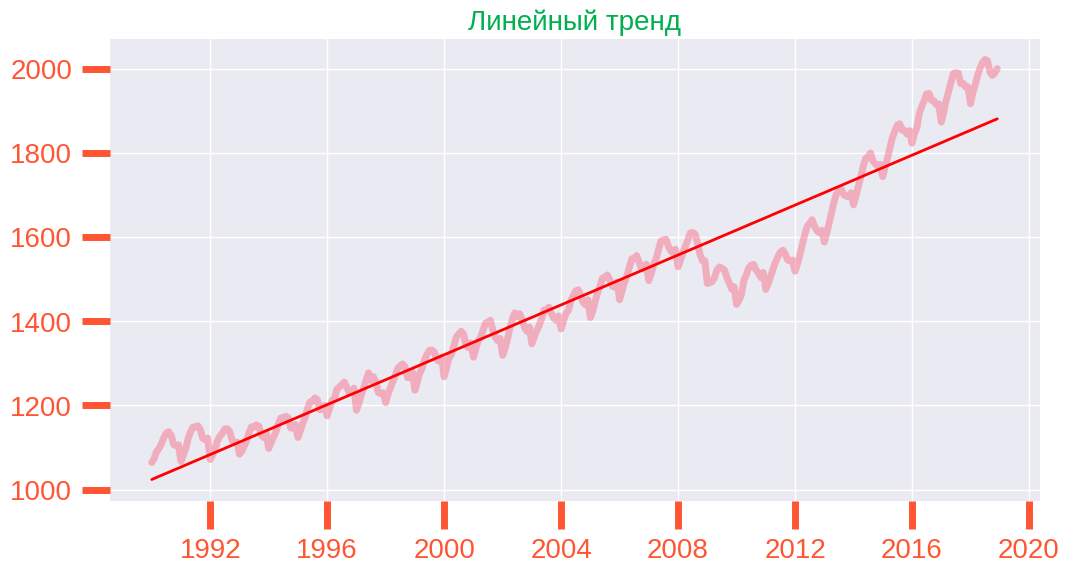

In [175]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.arange(len(data)).reshape(-1, 1)
y = data.iloc[:, 0].values

model = LinearRegression()
model.fit(X, y)
linear_trend = model.predict(X)

plt.figure(figsize=(12, 6))
plt.plot(data.index, data.iloc[:, 0], alpha=0.5)
plt.plot(data.index, linear_trend, color='red', linewidth=2)
plt.title('Линейный тренд')
plt.show()

1. тренд по скользяшему кажется линейно растущим +- до 2008 года, дальше просадка и выход обратно на тренд через пару лет
2. тренд линейный хорошо показывает рост занятости до 2008 года, но из-за следющей просадки в 2008 - 2012 годах плохо показывает тренд на будущие года, то есть он ниже реального тренда, к которому вернулась занятость после

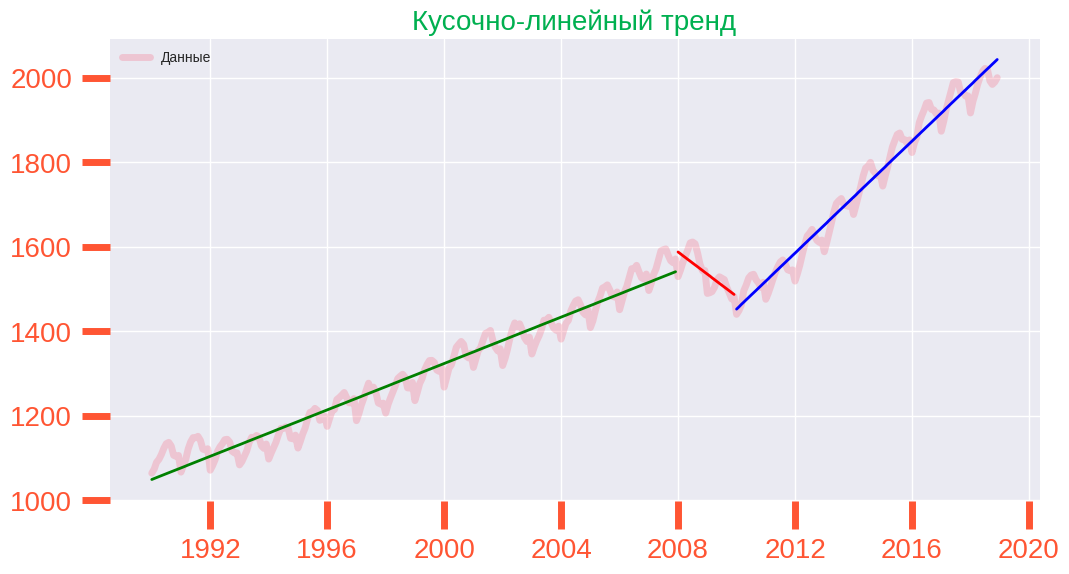

In [176]:
# Разбиваем на периоды
pre_crisis = data[:'2007']
crisis = data['2008':'2009']
recovery = data['2010':]

# Строим тренды для каждого периода
periods = [pre_crisis, crisis, recovery]
colors = ['green', 'red', 'blue']

plt.figure(figsize=(12, 6))
plt.plot(data.index, data.iloc[:, 0], alpha=0.3, label='Данные')

for period, color in zip(periods, colors):
    X = np.arange(len(period)).reshape(-1, 1)
    y = period.iloc[:, 0].values
    model = LinearRegression().fit(X, y)
    plt.plot(period.index, model.predict(X), color=color, linewidth=2)

plt.title('Кусочно-линейный тренд')
plt.legend()
plt.show()

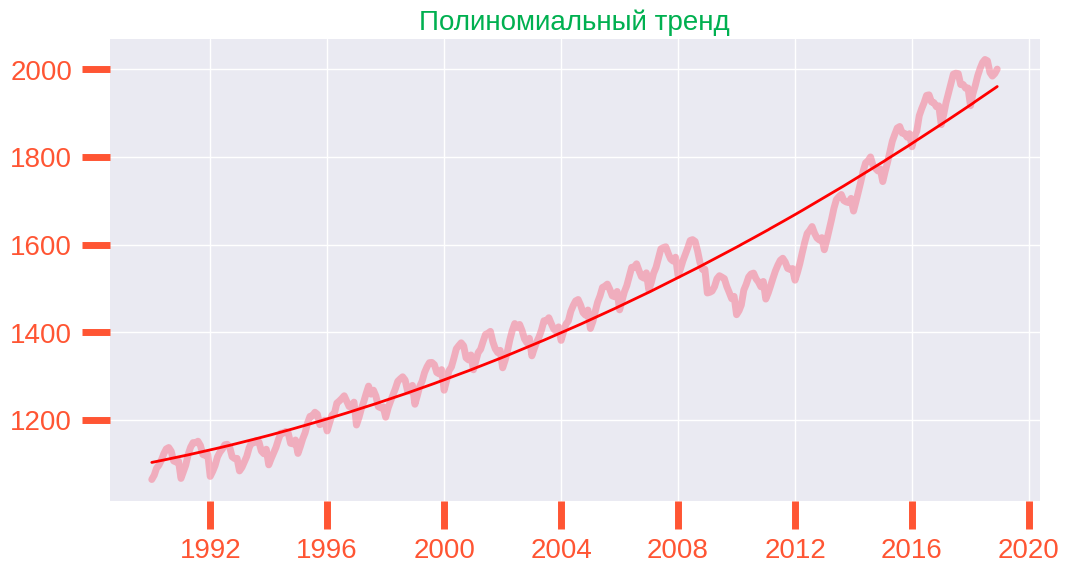

In [177]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X = np.arange(len(data)).reshape(-1, 1)
X_poly = poly.fit_transform(X)

model = LinearRegression().fit(X_poly, data.iloc[:, 0])
poly_trend = model.predict(X_poly)

plt.figure(figsize=(12, 6))
plt.plot(data.index, data.iloc[:, 0], alpha=0.5)
plt.plot(data.index, poly_trend, color='red', linewidth=2)
plt.title('Полиномиальный тренд')
plt.show()

Теперь намного более понятнее стал тренд по полиномиальной или кусочно-линейной зависимости, хотя в полиномиальной как будто все-таки просадка оказывает пагубное влияние на дальнейшую кривую.

## Проверка стационарности

ADF Statistic: 0.9012844235569791
p-value: 0.9931070655289933
Critical Values:
  1%: -3.4503224123605194
  5%: -2.870338478726661
  10%: -2.571457612488522
Ряд нестационарен (не отвергаем H0)


<Figure size 1200x400 with 0 Axes>

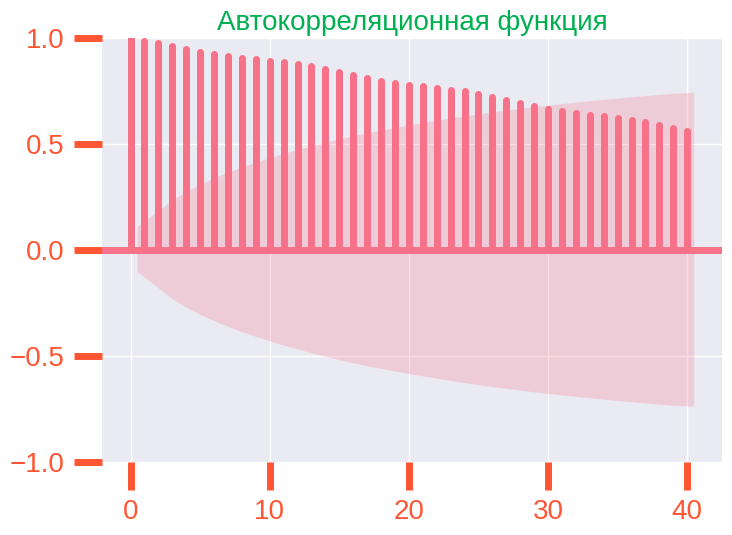

p-value после первой разности: 0.028991505238964523


In [178]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Тест Дики-Фуллера
result = adfuller(data.iloc[:, 0])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'  {key}: {value}')

# Вывод о стационарности
if result[1] <= 0.05:
    print("Ряд стационарен (отвергаем H0)")
else:
    print("Ряд нестационарен (не отвергаем H0)")

# График автокорреляции
plt.figure(figsize=(12, 4))
plot_acf(data.iloc[:, 0], lags=40, alpha=0.05)
plt.title('Автокорреляционная функция')
plt.show()

# Первая разность
data_diff = data.iloc[:, 0].diff().dropna()
result_diff = adfuller(data_diff)
print('p-value после первой разности:', result_diff[1])

Явное наличие тренда и сезонности, это нестационарный ряд.
Ряд становится стационарным после взятия первой разности, что подтверждает наличие выраженного тренда.

## Модель

In [179]:
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Просто используем данные как есть, без установки частоты
# data = data.asfreq('MS')  # Убрали эту строку

# Кросс-валидация
tscv = TimeSeriesSplit(n_splits=5)
models_metrics = {}

# 1. Сезонная модель
seasonal_mae, seasonal_rmse = [], []

for train_idx, test_idx in tscv.split(data):
    train_data = data.iloc[train_idx]
    test_data = data.iloc[test_idx]

    forecasts = []
    for month in test_data.index.month:
        month_avg = train_data[train_data.index.month == month].iloc[:, 0].mean()
        forecasts.append(month_avg)

    mae = mean_absolute_error(test_data.iloc[:, 0], forecasts)
    rmse = np.sqrt(mean_squared_error(test_data.iloc[:, 0], forecasts))

    seasonal_mae.append(mae)
    seasonal_rmse.append(rmse)

models_metrics['Seasonal'] = {
    'MAE': np.mean(seasonal_mae),
    'RMSE': np.mean(seasonal_rmse)
}

# 2. Holt-Winters
hw_mae, hw_rmse = [], []

for train_idx, test_idx in tscv.split(data):
    train_data = data.iloc[train_idx]
    test_data = data.iloc[test_idx]

    try:
        model = ExponentialSmoothing(train_data.iloc[:, 0], seasonal_periods=12, trend='add', seasonal='add')
        model_fit = model.fit()
        forecast = model_fit.forecast(len(test_data))

        mae = mean_absolute_error(test_data.iloc[:, 0], forecast)
        rmse = np.sqrt(mean_squared_error(test_data.iloc[:, 0], forecast))

        hw_mae.append(mae)
        hw_rmse.append(rmse)
    except Exception as e:
        print(f"Ошибка в Holt-Winters: {e}")
        continue

models_metrics['Holt-Winters'] = {
    'MAE': np.mean(hw_mae) if hw_mae else float('inf'),
    'RMSE': np.mean(hw_rmse) if hw_rmse else float('inf')
}

# 3. ARIMA
arima_mae, arima_rmse = [], []

for train_idx, test_idx in tscv.split(data):
    train_data = data.iloc[train_idx]
    test_data = data.iloc[test_idx]

    try:
        model = ARIMA(train_data.iloc[:, 0], order=(1,1,1))
        model_fit = model.fit()
        forecast = model_fit.forecast(len(test_data))

        mae = mean_absolute_error(test_data.iloc[:, 0], forecast)
        rmse = np.sqrt(mean_squared_error(test_data.iloc[:, 0], forecast))

        arima_mae.append(mae)
        arima_rmse.append(rmse)
    except Exception as e:
        print(f"Ошибка в ARIMA: {e}")
        continue

models_metrics['ARIMA'] = {
    'MAE': np.mean(arima_mae) if arima_mae else float('inf'),
    'RMSE': np.mean(arima_rmse) if arima_rmse else float('inf')
}

# Результаты
print("Сравнение моделей:")
for name, metrics in models_metrics.items():
    if metrics['RMSE'] != float('inf'):
        print(f"{name}: MAE={metrics['MAE']:.1f}, RMSE={metrics['RMSE']:.1f}")
    else:
        print(f"{name}: Не удалось вычислить метрики")

# Лучшая модель (исключая модели с ошибками)
valid_models = {name: metrics for name, metrics in models_metrics.items()
               if metrics['RMSE'] != float('inf')}
if valid_models:
    best_model = min(valid_models.items(), key=lambda x: x[1]['RMSE'])
    print(f"\nЛучшая модель: {best_model[0]} (RMSE={best_model[1]['RMSE']:.1f})")
else:
    print("\nВсе модели завершились с ошибками")

Сравнение моделей:
Seasonal: MAE=273.9, RMSE=279.8
Holt-Winters: MAE=83.4, RMSE=100.3
ARIMA: MAE=96.0, RMSE=110.9

Лучшая модель: Holt-Winters (RMSE=100.3)


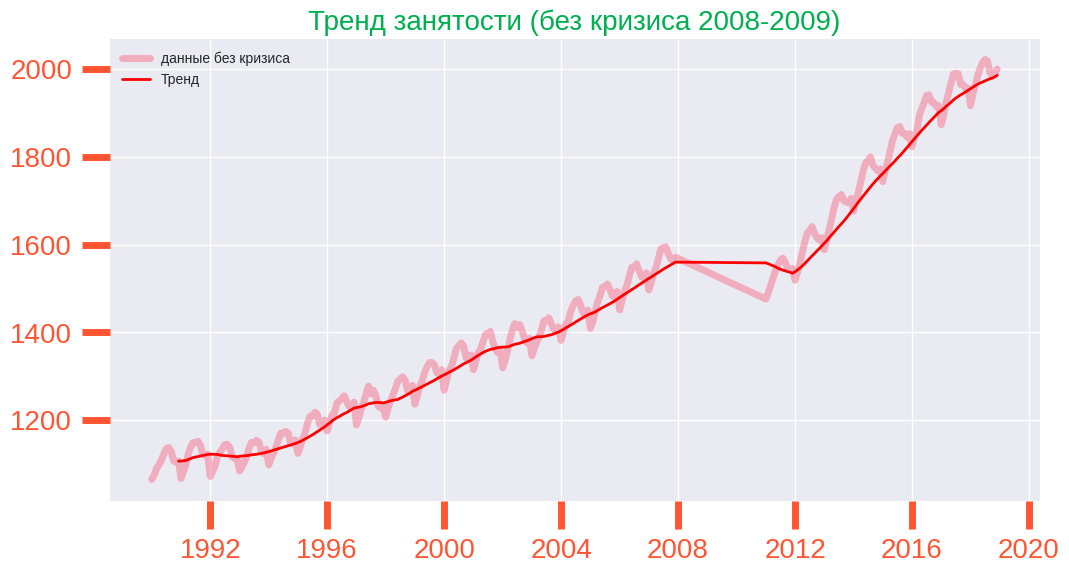

In [180]:
# Разбиваем на периоды
pre_crisis = data[:'2007']
crisis = data['2008':'2009']
recovery = data['2010':]

# Фильтруем данные - исключаем кризисный период 2008-2009
data_filtered = data[(data.index < '2008-01-01') | (data.index > '2010-12-31')].copy()
data_filtered = data_filtered.sort_index()

# Скользящее среднее для тренда
window = 12
trend = data_filtered.iloc[:, 0].rolling(window=window).mean()

# График с трендом
plt.figure(figsize=(12, 6))
plt.plot(data_filtered.index, data_filtered.iloc[:, 0], alpha=0.5, label='данные без кризиса')
plt.plot(data_filtered.index, trend, linewidth=2, label='Тренд', color='red')
plt.title('Тренд занятости (без кризиса 2008-2009)')
plt.legend()
plt.grid(True)
plt.show()

In [181]:
data_filtered.head()

,Employees
Date,
1990-01-01,1064.5
1990-02-01,1074.5
1990-03-01,1090.0
1990-04-01,1097.4
1990-05-01,1108.7


In [182]:
data_filtered.iloc[:, 0].isna().sum()

np.int64(0)

In [183]:
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


print(f"Размер датасета после фильтрации: {len(data_filtered)}")
print(f"Количество пропусков: {data_filtered.iloc[:, 0].isna().sum()}")

# Кросс-валидация
tscv = TimeSeriesSplit(n_splits=5)
models_metrics = {}

# 1. Сезонная модель
seasonal_mae, seasonal_rmse = [], []

for train_idx, test_idx in tscv.split(data_filtered):
    train_data = data_filtered.iloc[train_idx]
    test_data = data_filtered.iloc[test_idx]

    forecasts = []
    for month in test_data.index.month:
        month_avg = train_data[train_data.index.month == month].iloc[:, 0].mean()
        forecasts.append(month_avg)

    mae = mean_absolute_error(test_data.iloc[:, 0], forecasts)
    rmse = np.sqrt(mean_squared_error(test_data.iloc[:, 0], forecasts))

    seasonal_mae.append(mae)
    seasonal_rmse.append(rmse)

models_metrics['Seasonal'] = {
    'MAE': np.mean(seasonal_mae),
    'RMSE': np.mean(seasonal_rmse)
}

# 2. Holt-Winters
hw_mae, hw_rmse = [], []

for train_idx, test_idx in tscv.split(data_filtered):
    train_data = data_filtered.iloc[train_idx]
    test_data = data_filtered.iloc[test_idx]

    try:

        model = ExponentialSmoothing(train_data.iloc[:, 0],
                                   seasonal_periods=12,
                                   trend='add',
                                   seasonal='add')
        model_fit = model.fit(smoothing_level=0.3,
                            smoothing_trend=0.1,
                            smoothing_seasonal=0.3,
                            optimized=False)

        forecast = model_fit.forecast(len(test_data))

        mae = mean_absolute_error(test_data.iloc[:, 0], forecast)
        rmse = np.sqrt(mean_squared_error(test_data.iloc[:, 0], forecast))

        hw_mae.append(mae)
        hw_rmse.append(rmse)

    except Exception as e:
        print(f"Ошибка в Holt-Winters: {e}")
        continue

models_metrics['Holt-Winters'] = {
    'MAE': np.mean(hw_mae) if hw_mae else float('inf'),
    'RMSE': np.mean(hw_rmse) if hw_rmse else float('inf')
}

# 3. ARIMA с сезонностью
arima_mae, arima_rmse = [], []

for train_idx, test_idx in tscv.split(data_filtered):
    train_data = data_filtered.iloc[train_idx]
    test_data = data_filtered.iloc[test_idx]

    try:
        # Сезонная ARIMA (SARIMA) с сезонным периодом 12 месяцев
        model = ARIMA(train_data.iloc[:, 0],
                     order=(1,1,1),           # несезонные параметры
                     seasonal_order=(1,1,1,12))  # сезонные параметры (P,D,Q,s)
        model_fit = model.fit()
        forecast = model_fit.forecast(len(test_data))

        mae = mean_absolute_error(test_data.iloc[:, 0], forecast)
        rmse = np.sqrt(mean_squared_error(test_data.iloc[:, 0], forecast))

        arima_mae.append(mae)
        arima_rmse.append(rmse)

    except Exception as e:
        print(f"Ошибка в ARIMA: {e}")
        # Пробуем обычный ARIMA если сезонный не работает
        try:
            model = ARIMA(train_data.iloc[:, 0], order=(1,1,1))
            model_fit = model.fit()
            forecast = model_fit.forecast(len(test_data))

            mae = mean_absolute_error(test_data.iloc[:, 0], forecast)
            rmse = np.sqrt(mean_squared_error(test_data.iloc[:, 0], forecast))

            arima_mae.append(mae)
            arima_rmse.append(rmse)
        except:
            continue

models_metrics['ARIMA'] = {
    'MAE': np.mean(arima_mae) if arima_mae else float('inf'),
    'RMSE': np.mean(arima_rmse) if arima_rmse else float('inf')
}

# Результаты
print("\nСравнение моделей на отфильтрованных данных:")
for name, metrics in models_metrics.items():
    if metrics['RMSE'] != float('inf'):
        print(f"{name}: MAE={metrics['MAE']:.1f}, RMSE={metrics['RMSE']:.1f}")
    else:
        print(f"{name}: Не удалось вычислить метрики")

# Лучшая модель (исключая модели с ошибками)
valid_models = {name: metrics for name, metrics in models_metrics.items()
               if metrics['RMSE'] != float('inf')}
if valid_models:
    best_model = min(valid_models.items(), key=lambda x: x[1]['RMSE'])
    print(f"\nЛучшая модель: {best_model[0]} (RMSE={best_model[1]['RMSE']:.1f})")
else:
    print("\nВсе модели завершились с ошибками")

Размер датасета после фильтрации: 312
Количество пропусков: 0

Сравнение моделей на отфильтрованных данных:
Seasonal: MAE=279.9, RMSE=285.7
Holt-Winters: MAE=28.1, RMSE=34.7
ARIMA: MAE=34.6, RMSE=39.7

Лучшая модель: Holt-Winters (RMSE=34.7)


ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ ИЗ КРОСС-ВАЛИДАЦИИ
Получаем прогнозы моделей...


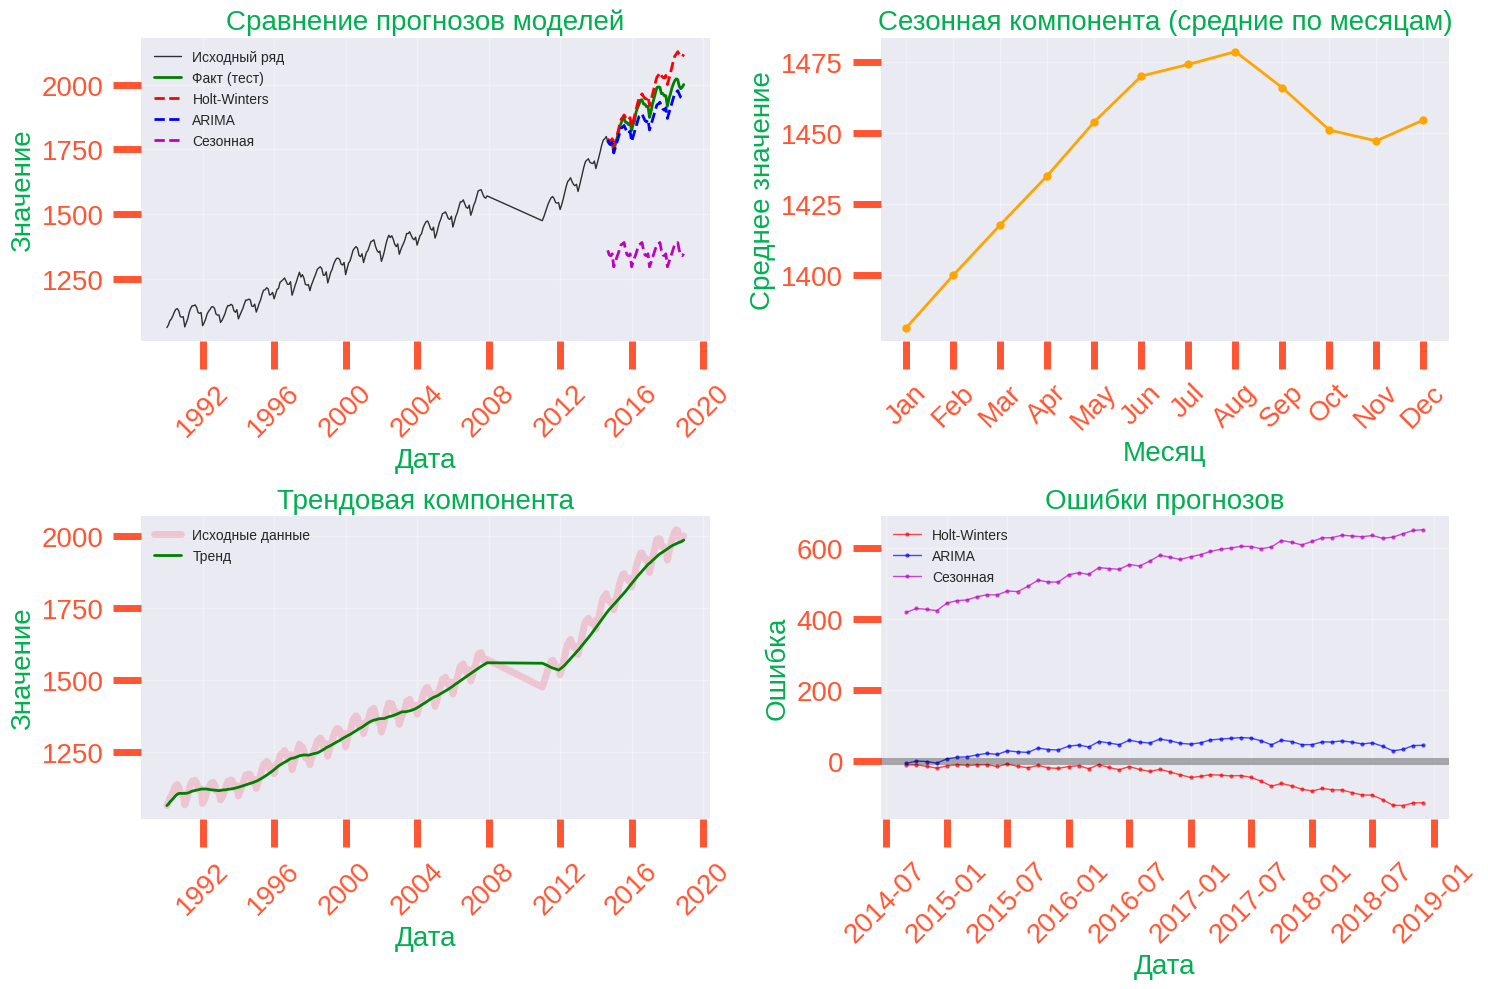


ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ПОСЛЕДНЕЙ ИТЕРАЦИИ КРОСС-ВАЛИДАЦИИ

МЕТРИКИ КАЧЕСТВА (последняя итерация):
Holt-Winters: MAE = 43.7
ARIMA: MAE = 41.5
Сезонная модель: MAE = 554.4

СЕЗОННАЯ КОМПОНЕНТА:
• Максимум: Aug (1478.6)
• Минимум: Jan (1381.5)
• Амплитуда: 97.0

ТРЕНДОВАЯ КОМПОНЕНТА:
• Направление: восходящий
• Изменение за период: 921.6

СРАВНИТЕЛЬНЫЙ АНАЛИЗ:
• Лучшая модель на последней итерации: ARIMA (MAE=41.5)
• Сезонность сильно влияет на прогноз
• Holt-Winters учитывает сезонность


In [184]:
# ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ ИЗ КРОСС-ВАЛИДАЦИИ
print("ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ ИЗ КРОСС-ВАЛИДАЦИИ")

# Берем последнюю итерацию кросс-валидации
tscv = TimeSeriesSplit(n_splits=5)
splits = list(tscv.split(data_filtered))
train_idx, test_idx = splits[-1]  # последняя итерация

train_data = data_filtered.iloc[train_idx]
test_data = data_filtered.iloc[test_idx]

# Получаем прогнозы из уже обученных моделей (последняя итерация)
print("Получаем прогнозы моделей...")

# Holt-Winters прогноз для последней итерации
hw_model = ExponentialSmoothing(train_data.iloc[:, 0],
                              seasonal_periods=12,
                              trend='add',
                              seasonal='add')
hw_fit = hw_model.fit(smoothing_level=0.3,
                     smoothing_trend=0.1,
                     smoothing_seasonal=0.3,
                     optimized=False)
hw_forecast = hw_fit.forecast(len(test_data))

# ARIMA прогноз для последней итерации
try:
    arima_model = ARIMA(train_data.iloc[:, 0], order=(1,1,1), seasonal_order=(1,1,1,12))
    arima_fit = arima_model.fit()
    arima_forecast = arima_fit.forecast(len(test_data))
except:
    arima_model = ARIMA(train_data.iloc[:, 0], order=(1,1,1))
    arima_fit = arima_model.fit()
    arima_forecast = arima_fit.forecast(len(test_data))

# Сезонная модель прогноз для последней итерации
seasonal_forecast = []
for month in test_data.index.month:
    month_avg = train_data[train_data.index.month == month].iloc[:, 0].mean()
    seasonal_forecast.append(month_avg)
seasonal_forecast = pd.Series(seasonal_forecast, index=test_data.index)

# Визуализация
plt.figure(figsize=(15, 10))

# 1. Все прогнозы вместе
plt.subplot(2, 2, 1)
plt.plot(data_filtered.index, data_filtered.iloc[:, 0], 'k-', label='Исходный ряд', alpha=0.8, linewidth=1)
plt.plot(test_data.index, test_data.iloc[:, 0], 'g-', label='Факт (тест)', linewidth=2)
plt.plot(test_data.index, hw_forecast.values, 'r--', label='Holt-Winters', linewidth=2)
plt.plot(test_data.index, arima_forecast.values, 'b--', label='ARIMA', linewidth=2)
plt.plot(test_data.index, seasonal_forecast.values, 'm--', label='Сезонная', linewidth=2)
plt.title('Сравнение прогнозов моделей')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# 2. Сезонная компонента
plt.subplot(2, 2, 2)
monthly_avg = data_filtered.groupby(data_filtered.index.month).mean()
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.plot(months, monthly_avg.iloc[:, 0], 'o-', linewidth=2, markersize=6, color='orange')
plt.title('Сезонная компонента (средние по месяцам)')
plt.xlabel('Месяц')
plt.ylabel('Среднее значение')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# 3. Трендовая компонента
plt.subplot(2, 2, 3)
trend = data_filtered.iloc[:, 0].rolling(window=12, min_periods=1).mean()
plt.plot(data_filtered.index, data_filtered.iloc[:, 0], alpha=0.3, label='Исходные данные')
plt.plot(data_filtered.index, trend, 'g-', linewidth=2, label='Тренд')
plt.title('Трендовая компонента')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# 4. Ошибки прогнозов
plt.subplot(2, 2, 4)
hw_errors = test_data.iloc[:, 0].values - hw_forecast.values
arima_errors = test_data.iloc[:, 0].values - arima_forecast.values
seasonal_errors = test_data.iloc[:, 0].values - seasonal_forecast.values

plt.plot(test_data.index, hw_errors, 'ro-', label='Holt-Winters', linewidth=1, markersize=3, alpha=0.7)
plt.plot(test_data.index, arima_errors, 'bo-', label='ARIMA', linewidth=1, markersize=3, alpha=0.7)
plt.plot(test_data.index, seasonal_errors, 'mo-', label='Сезонная', linewidth=1, markersize=3, alpha=0.7)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.title('Ошибки прогнозов')
plt.xlabel('Дата')
plt.ylabel('Ошибка')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
print("\n" + "="*70)
print("ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ ПОСЛЕДНЕЙ ИТЕРАЦИИ КРОСС-ВАЛИДАЦИИ")
print("="*70)

# Метрики для последней итерации
hw_mae_last = mean_absolute_error(test_data.iloc[:, 0], hw_forecast)
arima_mae_last = mean_absolute_error(test_data.iloc[:, 0], arima_forecast)
seasonal_mae_last = mean_absolute_error(test_data.iloc[:, 0], seasonal_forecast)

print(f"\nМЕТРИКИ КАЧЕСТВА (последняя итерация):")
print(f"Holt-Winters: MAE = {hw_mae_last:.1f}")
print(f"ARIMA: MAE = {arima_mae_last:.1f}")
print(f"Сезонная модель: MAE = {seasonal_mae_last:.1f}")

# Анализ сезонности
print(f"\nСЕЗОННАЯ КОМПОНЕНТА:")
max_month = monthly_avg.iloc[:, 0].idxmax()
min_month = monthly_avg.iloc[:, 0].idxmin()
amplitude = monthly_avg.iloc[:, 0].max() - monthly_avg.iloc[:, 0].min()

print(f"• Максимум: {months[max_month-1]} ({monthly_avg.iloc[max_month-1, 0]:.1f})")
print(f"• Минимум: {months[min_month-1]} ({monthly_avg.iloc[min_month-1, 0]:.1f})")
print(f"• Амплитуда: {amplitude:.1f}")

# Анализ тренда
print(f"\nТРЕНДОВАЯ КОМПОНЕНТА:")
trend_change = trend.iloc[-1] - trend.iloc[0]
if trend_change > 0:
    direction = "восходящий"
elif trend_change < 0:
    direction = "нисходящий"
else:
    direction = "стабильный"

print(f"• Направление: {direction}")
print(f"• Изменение за период: {trend_change:.1f}")

# Сравнение моделей
print(f"\nСРАВНИТЕЛЬНЫЙ АНАЛИЗ:")
best_model_local = min([
    ('Holt-Winters', hw_mae_last),
    ('ARIMA', arima_mae_last),
    ('Сезонная', seasonal_mae_last)
], key=lambda x: x[1])

print(f"• Лучшая модель на последней итерации: {best_model_local[0]} (MAE={best_model_local[1]:.1f})")
print(f"• Сезонность {'сильно' if amplitude > 20 else 'умеренно'} влияет на прогноз")
print(f"• Holt-Winters {'учитывает' if hw_fit.params['smoothing_seasonal'] > 0 else 'игнорирует'} сезонность")

**ВЫВОД:**  После анализа датасета временного ряда определено, что ARIMA модель демонстрирует наилучшую точность прогноза (MAE=41.5), немного опережая Holt-Winters (MAE=43.7). А сезонная модель ужасно показала себя. Данные характеризуются сильным восходящим трендом и выраженной сезонностью. Пик занятости приходится на лето, а минимальные значения находятся зимой, что логично, это же курортный отдых. Честно говоря, если подобрать оптимальные настройки Holt-Winters, то эта модель может оказаться лучше, но как будто она больше склонна к переобучению

p.s. я до этого не сталкивался с таким родом задач, поэтому для меня было совсем в новинку, пришлось прибегать к помощи интернет-ресурсов, к сожалению.